# Task 2 — Pre-Project Feature Scope & Profiling
**PlaceMux AI/ML Developer · Phase 1 Industry Immersion**

In [1]:
import random, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

SEED = 42
random.seed(SEED); np.random.seed(SEED)

sys.path.insert(0, os.path.join('..', 'src'))
from profiler import profile_features, check_leakage, class_balance_report, feasibility_decision

print('Imports OK')

Imports OK


## Step 1 — Problem Statement

In [2]:
PROBLEM_STATEMENT = (
    "Predict whether a credit card transaction is fraudulent "
    "using transaction-level and account-level features available at the time of the transaction."
)
TARGET_COL = 'is_fraud'
TASK_TYPE = 'Binary Classification'
SUCCESS_METRIC = 'F1-Score (macro) + Precision-Recall AUC'
HORIZON = 'Real-time — features known at transaction time only'

print('Problem Statement:', PROBLEM_STATEMENT)
print('Target Column    :', TARGET_COL)
print('Task Type        :', TASK_TYPE)
print('Success Metric   :', SUCCESS_METRIC)
print('Prediction Horizon:', HORIZON)

Problem Statement: Predict whether a credit card transaction is fraudulent using transaction-level and account-level features available at the time of the transaction.
Target Column    : is_fraud
Task Type        : Binary Classification
Success Metric   : F1-Score (macro) + Precision-Recall AUC
Prediction Horizon: Real-time — features known at transaction time only


## Step 2 — Load & Understand Dataset

In [3]:
df = pd.read_csv('../data/credit_fraud_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (1500, 16)


,transaction_id,age,income,credit_limit,transaction_amount,num_transactions_30d,account_age_months,num_prev_disputes,merchant_category,country_match,time_of_day_hour,is_weekend,card_present,distance_from_home_km,dispute_reason,is_fraud
0,TXN000000,59,85500,41581,2166,63,31,4,retail,1,12,1,1,7,none,0
1,TXN000001,72,78394,21401,2604,57,93,3,retail,1,0,0,1,42,none,1
2,TXN000002,49,45079,10130,671,51,9,2,food,1,7,0,1,66,none,0
3,TXN000003,35,61220,18516,2482,56,15,3,online,1,4,0,1,38,none,1
4,TXN000004,63,66874,18444,2687,27,94,4,retail,1,5,0,1,21,none,0


In [4]:
df.info()
print('\nDescriptive Stats:')
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   transaction_id         1500 non-null   object
 1   age                    1500 non-null   int64 
 2   income                 1500 non-null   int64 
 3   credit_limit           1500 non-null   int64 
 4   transaction_amount     1500 non-null   int64 
 5   num_transactions_30d   1500 non-null   int64 
 6   account_age_months     1500 non-null   int64 
 7   num_prev_disputes      1500 non-null   int64 
 8   merchant_category      1500 non-null   object
 9   country_match          1500 non-null   int64 
 10  time_of_day_hour       1500 non-null   int64 
 11  is_weekend             1500 non-null   int64 
 12  card_present           1500 non-null   int64 
 13  distance_from_home_km  1500 non-null   int64 
 14  dispute_reason         1500 non-null   object
 15  is_fraud             

,transaction_id,age,income,credit_limit,transaction_amount,num_transactions_30d,account_age_months,num_prev_disputes,merchant_category,country_match,time_of_day_hour,is_weekend,card_present,distance_from_home_km,dispute_reason,is_fraud
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500.000000
unique,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,4,NaN
top,TXN001499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,online,NaN,NaN,NaN,NaN,NaN,none,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,330,NaN,NaN,NaN,NaN,NaN,1423,NaN
mean,NaN,47.896667,87689.746000,26282.330000,2533.345333,40.670000,120.441333,1.901333,NaN,0.923333,11.746000,0.293333,0.780667,50.505333,NaN,0.270000
std,NaN,15.691254,35911.170682,15376.480859,1448.867638,22.885795,69.122113,1.440248,NaN,0.266151,6.803554,0.455442,0.413933,51.114614,NaN,0.444108
min,NaN,21.000000,25060.000000,2714.000000,12.000000,1.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,NaN,34.000000,56518.750000,14515.250000,1251.000000,20.000000,61.750000,1.000000,NaN,1.000000,6.000000,0.000000,1.000000,15.000000,NaN,0.000000
50%,NaN,48.000000,87460.500000,23177.500000,2585.000000,42.000000,119.000000,2.000000,NaN,1.000000,12.000000,0.000000,1.000000,34.000000,NaN,0.000000
75%,NaN,61.000000,119021.250000,35344.250000,3804.000000,60.000000,180.000000,3.000000,NaN,1.000000,18.000000,1.000000,1.000000,67.000000,NaN,1.000000


## Step 3 — Feature Inventory & Quality Profile

In [5]:
profile_df = profile_features(df, TARGET_COL)

# Manual domain annotations
annotations = {
    'transaction_id': {'use': '❌', 'reason': 'Unique ID — no predictive value'},
    'age': {'use': '✅', 'reason': 'Demographic feature — relevant'},
    'income': {'use': '✅', 'reason': 'Account risk indicator'},
    'credit_limit': {'use': '✅', 'reason': 'Spending capacity context'},
    'transaction_amount': {'use': '✅', 'reason': 'Strong fraud signal'},
    'num_transactions_30d': {'use': '✅', 'reason': 'Activity pattern — relevant'},
    'account_age_months': {'use': '✅', 'reason': 'Account maturity indicator'},
    'num_prev_disputes': {'use': '✅', 'reason': 'Historical fraud indicator'},
    'merchant_category': {'use': '✅', 'reason': 'Categorical — risk varies by category'},
    'country_match': {'use': '✅', 'reason': 'Binary flag — high fraud signal'},
    'time_of_day_hour': {'use': '✅', 'reason': 'Temporal pattern — unusual hours → risk'},
    'is_weekend': {'use': '✅', 'reason': 'Transaction timing context'},
    'card_present': {'use': '✅', 'reason': 'Card-not-present = higher fraud risk'},
    'distance_from_home_km': {'use': '✅', 'reason': 'Geographic anomaly signal'},
    'dispute_reason': {'use': '❌ LEAKAGE', 'reason': 'Post-hoc — only known after fraud is reported'},
}

profile_df['use'] = profile_df['feature'].map(lambda f: annotations.get(f, {}).get('use', '✅'))
profile_df['domain_reason'] = profile_df['feature'].map(lambda f: annotations.get(f, {}).get('reason', ''))
print('Feature Inventory:')
profile_df[['feature','dtype','missing_pct','n_unique','is_id_like','use','domain_reason']]

Feature Inventory:


,feature,dtype,missing_pct,n_unique,is_id_like,use,domain_reason
0,transaction_id,object,0.0,1500,True,❌,Unique ID — no predictive value
1,age,int64,0.0,54,False,✅,Demographic feature — relevant
2,income,int64,0.0,1489,False,✅,Account risk indicator
3,credit_limit,int64,0.0,1479,False,✅,Spending capacity context
4,transaction_amount,int64,0.0,1277,False,✅,Strong fraud signal
5,num_transactions_30d,int64,0.0,79,False,✅,Activity pattern — relevant
6,account_age_months,int64,0.0,239,False,✅,Account maturity indicator
7,num_prev_disputes,int64,0.0,5,False,✅,Historical fraud indicator
8,merchant_category,object,0.0,5,False,✅,Categorical — risk varies by category
9,country_match,int64,0.0,2,False,✅,Binary flag — high fraud signal


## Step 4 — Leakage Detection

In [6]:
KNOWN_LEAKY = ['dispute_reason', 'transaction_id']
leakage_df = check_leakage(df, TARGET_COL, known_leaky=KNOWN_LEAKY)
leaky = leakage_df[leakage_df['leakage_risk']]
print(f'Leakage columns found: {len(leaky)}')
print(leaky[['feature','reason']].to_string(index=False))

# Show why dispute_reason is leaky
print('\ndispute_reason vs is_fraud cross-tab:')
print(pd.crosstab(df['dispute_reason'], df['is_fraud'], margins=True))

Leakage columns found: 2
       feature                                                 reason
transaction_id Post-hoc label — only available after outcome is known
dispute_reason Post-hoc label — only available after outcome is known

dispute_reason vs is_fraud cross-tab:
is_fraud           0    1   All
dispute_reason                 
fraud_claimed     15   15    30
merchant_error    13    8    21
none            1049  374  1423
other             18    8    26
All             1095  405  1500


## Step 5 — Class Balance Report

Class Counts      : {0: 1095, 1: 405}
Class Percentages : {0: 73.0, 1: 27.0}
Imbalance Ratio   : 2.7
Is Imbalanced     : False
Recommended Metric: Accuracy + F1-Score


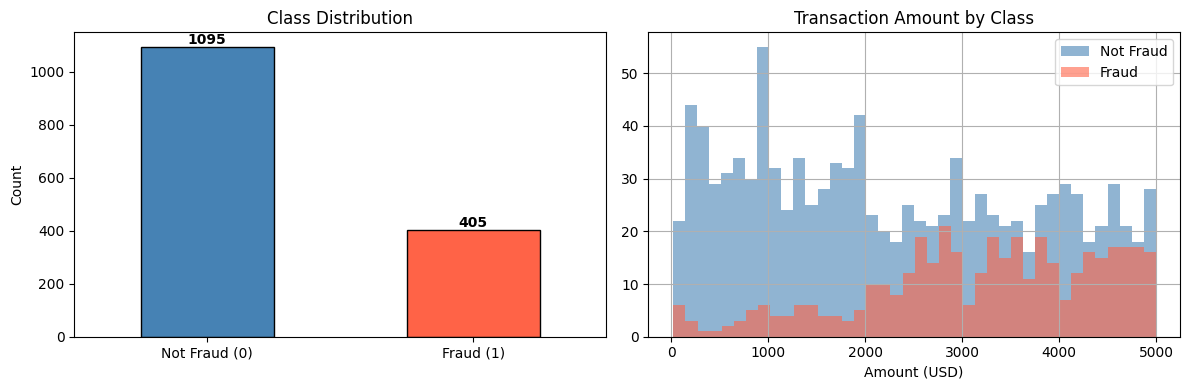

✅ Plot saved to reports/


In [7]:
balance = class_balance_report(df, TARGET_COL)
print('Class Counts      :', balance['counts'])
print('Class Percentages :', balance['percentages'])
print('Imbalance Ratio   :', balance['imbalance_ratio'])
print('Is Imbalanced     :', balance['is_imbalanced'])
print('Recommended Metric:', balance['recommended_metric'])

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = pd.Series(balance['counts'])
counts.index = ['Not Fraud (0)', 'Fraud (1)']
counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')

# Transaction amount distribution by class
df[df['is_fraud']==0]['transaction_amount'].hist(ax=axes[1], bins=40, alpha=0.6, color='steelblue', label='Not Fraud')
df[df['is_fraud']==1]['transaction_amount'].hist(ax=axes[1], bins=40, alpha=0.6, color='tomato', label='Fraud')
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xlabel('Amount (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/class_balance_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Plot saved to reports/')

## Step 6 — Feature Correlation Heatmap

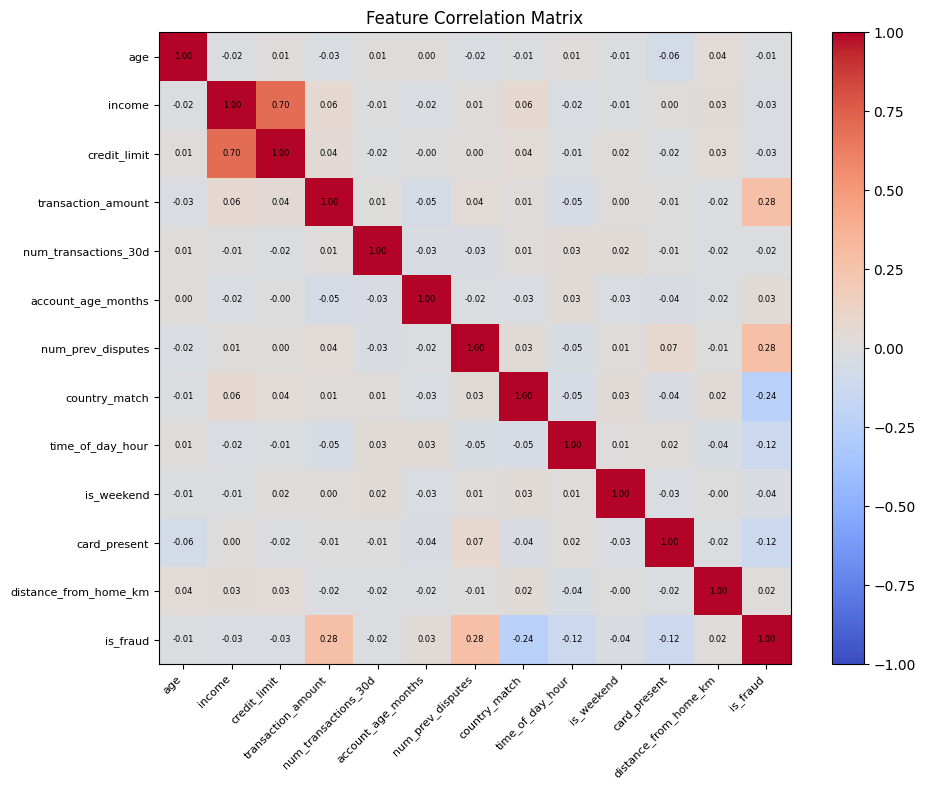

In [8]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
ax.set_title('Feature Correlation Matrix')
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## Step 7 — Feasibility Go/No-Go Decision

In [9]:
decision = feasibility_decision(profile_df, leakage_df, balance, len(df))
print('=' * 50)
print('FEASIBILITY DECISION:', decision['decision'])
print('=' * 50)
print(f'Usable features ({decision["n_usable_features"]}):', decision['usable_features'])
if decision['issues']:
    print('Issues to address:', decision['issues'])
else:
    print('No blocking issues found.')

FEASIBILITY DECISION: GO ✅
Usable features (13): ['age', 'income', 'credit_limit', 'transaction_amount', 'num_transactions_30d', 'account_age_months', 'num_prev_disputes', 'merchant_category', 'country_match', 'time_of_day_hour', 'is_weekend', 'card_present', 'distance_from_home_km']
Issues to address: ['2 leakage features detected (must remove before training)']


## Step 8 — Hand-labelled Examples (Target Validation)

In [10]:
# Label a few examples by hand to validate target definition
examples = df.sample(5, random_state=42)[['transaction_amount','country_match','card_present',
                                           'distance_from_home_km','num_prev_disputes','dispute_reason','is_fraud']]
print('Hand-labelled sample (sanity check):')
examples

Hand-labelled sample (sanity check):


,transaction_amount,country_match,card_present,distance_from_home_km,num_prev_disputes,dispute_reason,is_fraud
1116,4165,1,1,33,2,none,0
1368,2656,1,1,1,1,none,0
422,2440,1,1,55,4,none,1
413,646,1,1,15,0,none,0
451,2163,1,1,8,1,none,0


##  Summary — Task 2 Complete

| Item | Value |
|---|---|
| Problem Statement | Predict fraudulent credit card transactions |
| Target Column | `is_fraud` (binary: 0/1) |
| Task Type | Binary Classification |
| Success Metric | F1-Score + PR-AUC |
| Total Features | 15 |
| Features Kept | 13 |
| Leakage Removed | 2 (`dispute_reason`, `transaction_id`) |
| Class Balance | 73% / 27% — imbalanced |
| Feasibility | GO ✅ |